# $\chi_{UKQ}$-Space Inversion for Detachment-Limited Landscapes

This notebook provides a minimal example workflow for using this repository to invert detachment-limited landscapes in $\chi_{UKQ}$ space.

The code was developed to retrieve spatial patterns of rock uplift rate, $U(x,y)$, from detachment-limited landscapes under the steady-state assumption. The framework can also be used to invert for spatially variable erodibility, $K(x,y)$, and account for spatial variations in precipitation rate, $Q(x,y)$.

For a full description of the method, assumptions, and applications, see:

**Oryan et al. (2025)**  
https://doi.org/10.1029/2024JB030819

## 1. Prepare the DEM

Before running this notebook, download and project the DEM into a metric coordinate system, preferably UTM.

DEM preparation is described in:

```text
examples/prepare_dem.ipynb
```

This preprocessing can be done with GDAL, QGIS, Python, or similar GIS tools.

## 2. Import packages

In [1]:
# Optional interactive backend:
# %matplotlib widget
#
# If the widget backend does not display in VS Code, use:
# %matplotlib inline

import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# This notebook is assumed to be inside the examples/ directory,
# so we add the repository root directory to the Python path.
repo_root = Path.cwd().parent
sys.path.insert(0, str(repo_root))

# Repository-specific imports.
# If one of these imports fails, there is likely a problem with your Python environment
# or with the repository path added above.
import loadAndExportDem as load_dem
import chifrd
import frdplt


/opt/anaconda3/envs/invertchi/lib/python3.11/site-packages/scabbard/config.py:3: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


[Taichi] version 1.7.4, llvm 15.0.7, commit b4b956fd, osx, python 3.11.15


[I 05/01/26 20:48:39.783 63990576] [shell.py:_shell_pop_print@23] Graphical python shell detected, using wrapped sys.stdout


## Load the DEM and define river-extraction parameters

Next, load the prepared DEM. In this example, we use a DEM from the Santa Ynez region.

You also need to define two key parameters for extracting the river network:

- **Base level**: the elevation threshold used to define the downstream reference level.
- **Drainage-area threshold**: the minimum upstream drainage area required for a channel to be treated as a river.

These parameters control which channels are included in the analysis. Some trial and error is usually needed to isolate the detachment-limited part of the river network and avoid including small hillslope channels or poorly resolved tributaries.

For the Santa Ynez example, a base level of `30 m` works fairly well. A drainage-area threshold of `1e6 m²` also tends to work well, corresponding to  `1 km²`.

Loading dem...
getting stack and recs...
Getting rivers...
Retrieved 39805 river nodes in 107 basins


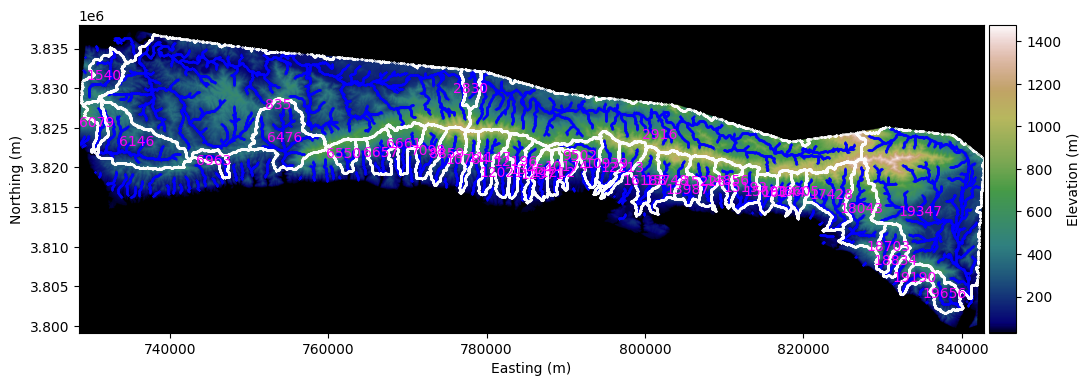

In [2]:

base_level = 30.0          # meters
area_threshold = 1e6       # m², equivalent to 1 km²

dem_path = "DEMs/santa_ynez.tif"

DEM = load_dem.loadDEMDiet(
    dem_path,
    Z0=base_level,
    A0=area_threshold,
)

fig, ax = plt.subplots(figsize=(16, 4))
DEM.PlotAll(ax=ax,numOfBasinsPrint=40)
plt.show()
fig_file = Path("figs") / "sy_retrieved_rivers_and_basins.pdf"
fig_file.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(fig_file, dpi=300)


## Select basins for inversion

Now it is time to choose the rivers for the inversion by selecting the basins you want to include.

You can either use the interactive figure mode to zoom in and out and identify the appropriate basins, or inspect the saved PDF version of the map.

In the basin-selection plot:

- rivers are shown in blue
- basin outlines are shown in white
- basin numbers are shown in magenta

For the Santa Ynez DEM, rivers north of the ridge are likely not detachment limited, or at least some portions of them may not be. In this example, we are therefore interested primarily in the rivers in the middle of the DEM.

Use the basin numbers to define the set of basins that will be included in the inversion.

In [4]:
from pathlib import Path

# Basin IDs selected from the basin-selection plot.
basinIDs = [
    6476, 18483, 18842, 21830, 18515, 15661, 16351,
    16691, 17714, 17918, 10012, 13983, 12946, 14234
]

# Define where to save the exported model input file.
# The output folder is created automatically if it does not already exist.
frd_model_file = Path("frdModels") / "sy_centralBasins.npz"
frd_model_file.parent.mkdir(parents=True, exist_ok=True)

# Export the selected basins.
DEM.ExportByBasins(str(frd_model_file), basinIDs=None)

print(f"Exported selected basins to: {frd_model_file}")

Did not get basinIDs, exporting all 39805 rivers


Exported selected basins to: frdModels/sy_centralBasins.npz


## Load the forward model

Now that the selected river basins have been exported, load them into the forward model.

You can continue experimenting by saving different combinations of river basins into separate `.npz` files and loading each file as a different forward model. This is useful for testing how the inversion depends on the selected rivers and basins.

If both `kx` and `ky` are provided, the inversion is performed in 2D. If only `kx` is provided, the inversion is performed in 1D.

I recommend using a relatively small number of knots, especially for small landscapes. See Oryan et al. (2025) for more details on choosing the parameterization.

In [13]:
frd_model_file = Path("frdModels") / "sy_centralBasins.npz"

# Number of inversion knots in each direction.
# Use both x and y knots for a 2D inversion.
# Use only number_of_knots_in_x for a 1D inversion.
number_of_knots_in_x = 1
number_of_knots_in_y = 1

f = chifrd.LoadFowardModel(
    str(frd_model_file),
    kx=number_of_knots_in_x,
    ky=number_of_knots_in_y,
)

frdplt.PlotFowardMapWithRiversNonSyn(f)

ValueError: zero-size array to reduction operation maximum which has no identity

In [6]:
DEM.riverData
DEM.riverData.columns

Index(['nodes', 'receivers', 'river_receivers', 'basinID', 'riverID', 'A',
       'Elevation', 'dx', 'flow_distance', 'rows', 'cols', 'X', 'Y'],
      dtype='str')

In [8]:
DEM.continentalDivide.columns

Index(['nodes', 'basinID', 'elevation', 'rows', 'cols', 'X', 'Y'], dtype='str')